#### Assignment 3

Theme: Bridging the Achievement Gap: An Analysis of EQAO Math Performance Across Ontario School Boards.

Focus: We will analyze the Grade 9 Math EQAO achievement rates and the correlation with a key demographic factor: Low-Income Households.

Dataset URL: https://data.ontario.ca/dataset/d85f68c5-fcb0-4b4d-aec5-3047db47dcd5/resource/f381e1de-3aa8-4ae9-826a-20009a6f4a01/download/new_sif_data_table_2023_24prelim_en_october2025.xlsx

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

In [30]:
# load Data
file_path = 'new_sif_data_table_2023_24prelim_en_october2025.xlsx'
# Read the first sheet of the Excel file
df = pd.read_excel(file_path)

In [31]:
df.columns

Index(['Board Number', 'Board Name', 'Board Type', 'School Number',
       'School Name', 'School Type', 'School Special Condition Code',
       'School Level', 'School Language', 'Grade Range', 'Building Suite',
       'P.O. Box', 'Street', 'Municipality', 'City', 'Province', 'Postal Code',
       'Phone Number', 'Fax Number', 'School Website', 'Board Website',
       'Enrolment', 'Latitude', 'Longitude',
       'Percentage of Students Whose First Language Is Not English',
       'Percentage of Students Whose First Language Is Not French',
       'Percentage of Students Who Are New to Canada from a Non-English Speaking Country',
       'Percentage of Students Who Are New to Canada from a Non-French Speaking Country',
       'Percentage of Students Receiving Special Education Services',
       'Percentage of Students Identified as Gifted',
       'Percentage of Grade 3 Students Achieving the Provincial Standard in Reading',
       'Change in Grade 3 Reading Achievement Over Three Years

In [32]:
# define some precise column names
math_col_g3 = 'Percentage of Grade 3 Students Achieving the Provincial Standard in Mathematics'
math_col_g9 = 'Percentage of Grade 9 Students Achieving the Provincial Standard in Mathematics'
reading_col_g3 = 'Percentage of Grade 3 Students Achieving the Provincial Standard in Reading'
low_income_col = 'Percentage of School-Aged Children Who Live in Low-Income Households'
newcomer_col = 'Percentage of Students Who Are New to Canada from a Non-English Speaking Country'
board_type_col = 'Board Type'

In [33]:
# convert to numeric (coerce errors to NaN)
for col in [math_col_g3, math_col_g9, reading_col_g3, low_income_col, newcomer_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# print descriptive statistics for selected columns
print("--- EQAO Achievement and Demographic Statistics (School Level) ---")
print("Note: 'count' shows the number of non-missing (non-suppressed) records.")

print("\nGrade 3 Math Achievement:")
print(df[math_col_g3].describe())

print("\nGrade 9 Math Achievement:")
print(df[math_col_g9].describe())

print("\nGrade 3 Reading Achievement:")
print(df[reading_col_g3].describe())

print("\nLow-Income Households Percentage:")
print(df[low_income_col].describe())

print("\nNewcomer Students Percentage:")
print(df[newcomer_col].describe())

--- EQAO Achievement and Demographic Statistics (School Level) ---
Note: 'count' shows the number of non-missing (non-suppressed) records.

Grade 3 Math Achievement:
count    3407.000000
mean        0.613302
std         0.179755
min         0.000000
25%         0.500000
50%         0.620000
75%         0.740000
max         1.000000
Name: Percentage of Grade 3 Students Achieving the Provincial Standard in Mathematics, dtype: float64

Grade 9 Math Achievement:
count    744.000000
mean       0.767151
std        5.158362
min        0.000000
25%        0.380000
50%        0.500000
75%        0.620000
max      100.000000
Name: Percentage of Grade 9 Students Achieving the Provincial Standard in Mathematics, dtype: float64

Grade 3 Reading Achievement:
count    3363.000000
mean        0.715795
std         0.160688
min         0.060000
25%         0.620000
50%         0.730000
75%         0.830000
max         1.000000
Name: Percentage of Grade 3 Students Achieving the Provincial Standard in Rea

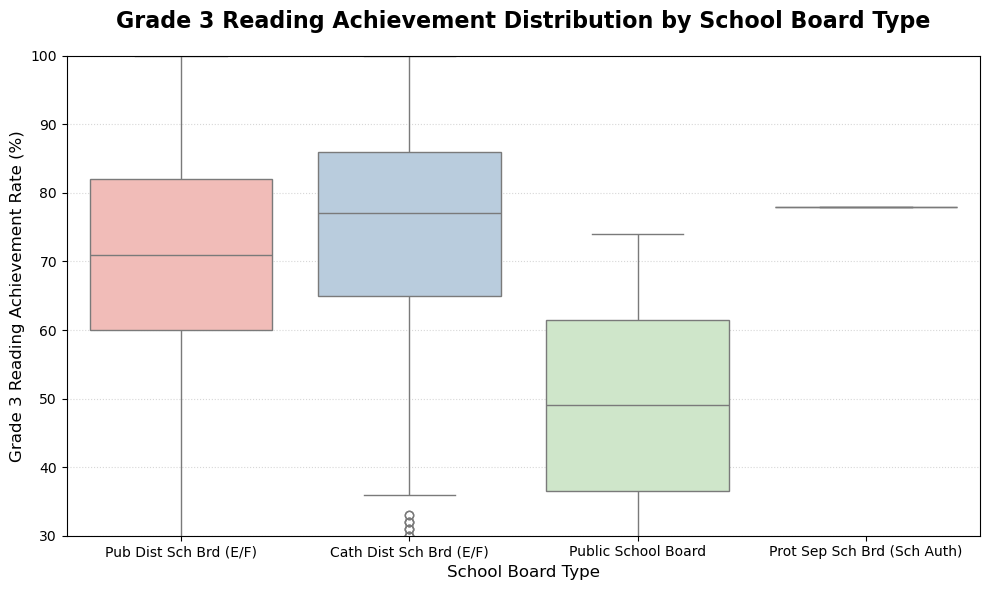

In [34]:
# multiply achievement rates by 100 to bring them into the 0-100% range
df[reading_col_g3] = df[reading_col_g3].apply(lambda x: x * 100 if x <= 1.0 else x)

# filter data (remove suppressed/missing data)
df_analysis = df.dropna(subset=[reading_col_g3, board_type_col]).copy()
# filter out schools reporting 0% or close to 0% achievement
df_analysis = df_analysis[df_analysis[reading_col_g3] > 5] 

# create isualization (Box Plot)
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=board_type_col, 
    y=reading_col_g3, 
    data=df_analysis, 
    hue=board_type_col,
    palette="Pastel1",
    legend=False
)

plt.title('Grade 3 Reading Achievement Distribution by School Board Type', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('School Board Type', fontsize=12)
plt.ylabel('Grade 3 Reading Achievement Rate (%)', fontsize=12)

plt.ylim(30, 100) # Set a lower limit to exclude any remaining extreme outliers and focus the view
plt.grid(axis='y', linestyle=':', alpha=0.5) 
plt.tight_layout()

# Save the visualization 
plt.savefig('visualization_1_from_python.png') 
plt.show()

#### Create a reproducible source to be used in Excel

In [36]:
board_name_col = 'Board Name'
output_file = 'top_10_boards_reading_data.xlsx'

# aggregate
# Group by Board Name and calculate the average achievement
board_averages = df.groupby(board_name_col)[reading_col_g3].mean().reset_index()

# Rename the aggregated column
board_averages.rename(columns={reading_col_g3: 'Average G3 Reading Achievement (%)'}, inplace=True)

# --- 4. Sort and Filter (Python replaces manual sorting/filtering) ---
# Sort the boards from highest average achievement to lowest
board_averages = board_averages.sort_values(
    by='Average G3 Reading Achievement (%)', 
    ascending=False
)

# Select the top 10 boards
top_10_boards = board_averages.head(10)

# --- 5. Output Reproducible Excel File ---
top_10_boards.to_excel(output_file, index=False)

print(f"Reproducible data for the Excel chart saved to: {output_file}")

Reproducible data for the Excel chart saved to: top_10_boards_reading_data.xlsx
